In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [72]:
dataset = pd.read_csv('./data/creditcard.csv')
dataset

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [73]:
dataset_arr = dataset.to_numpy()
X,y = dataset_arr[:,:-1].astype(np.float64),dataset_arr[:,-1].astype(np.uint8)
X,y

(array([[ 0.00000000e+00, -1.35980713e+00, -7.27811733e-02, ...,
          1.33558377e-01, -2.10530535e-02,  1.49620000e+02],
        [ 0.00000000e+00,  1.19185711e+00,  2.66150712e-01, ...,
         -8.98309914e-03,  1.47241692e-02,  2.69000000e+00],
        [ 1.00000000e+00, -1.35835406e+00, -1.34016307e+00, ...,
         -5.53527940e-02, -5.97518406e-02,  3.78660000e+02],
        ...,
        [ 1.72788000e+05,  1.91956501e+00, -3.01253846e-01, ...,
          4.45477214e-03, -2.65608286e-02,  6.78800000e+01],
        [ 1.72788000e+05, -2.40440050e-01,  5.30482513e-01, ...,
          1.08820735e-01,  1.04532821e-01,  1.00000000e+01],
        [ 1.72792000e+05, -5.33412522e-01, -1.89733337e-01, ...,
         -2.41530880e-03,  1.36489143e-02,  2.17000000e+02]],
       shape=(284807, 30)),
 array([0, 0, 0, ..., 0, 0, 0], shape=(284807,), dtype=uint8))

In [74]:
intercept = np.ones((X.shape[0],1))
X_b = np.concatenate((intercept,X),axis =1)

In [75]:
n_classes=np.unique(y,axis=0).shape[0]
n_samples = y.shape[0]
print(n_classes,n_samples)
y_encoded = np.array([np.zeros(n_classes) for i in range (n_samples)])
y_encoded[np.arange(n_samples),y] = 1

2 284807


In [76]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle=True

X_train,X_val,y_train,y_val = train_test_split(X_b,y_encoded,test_size = val_size,random_state=random_state,shuffle=is_shuffle)
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=test_size,random_state=random_state,shuffle=is_shuffle)


In [77]:
normalizer = StandardScaler()
X_train[:,1:] = normalizer.fit_transform(X_train[:,1:])
X_val[:,1:]=normalizer.transform(X_val[:,1:])
X_test[:,1:]=normalizer.transform(X_test[:,1:])

In [78]:
def softmax(z):
    exp_z = np.exp(z-np.max(z,axis=1,keepdims=True))
    return exp_z/exp_z.sum(axis=1)[:,None]
def predict(X,theta):
    z=np.dot(X,theta)
    y_hat=softmax(z)
    return y_hat
def compute_loss(y_hat,y):
    n=y.shape[0]
    return (-1/n)*np.sum(y*np.log(y_hat+1e-15))
def compute_gradient(X,y,y_hat):
    n=y.shape[0]
    return np.dot(X.T,(y_hat-y))/n
def update_theta(theta,gradient,lr):
    return theta-lr*gradient
def compute_accuracy(X,y,theta):
    y_hat = predict(X,theta)
    acc = (np.argmax(y_hat, axis=1) == np.argmax(y, axis=1)).mean()
    return acc

In [79]:
lr = 0.01
epochs = 30
batch_size = 1024
n_feature = X_train.shape[1]
np.random.seed(random_state)
theta = np.random.uniform(size=(n_feature,n_classes))  # ✅ Dùng X_train thay vì X_b
print(theta)
train_losses = []
val_losses = []
train_accs = []
val_accs = []
for epoch in range(epochs):
    train_batch_losses =[]
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]
        
        y_hat = predict(X_i,theta)
        
        train_loss = compute_loss(y_hat,y_i)

        gradient = compute_gradient(X_i,y_i,y_hat)
        
        theta = update_theta(theta,gradient,lr)
        
        train_batch_losses.append(train_loss)
        train_acc = compute_accuracy(X_train, y_train, theta)  # ✅ Truyền X_i thay vì y_hat
        train_batch_accs.append(train_acc)

        y_val_hat = predict(X_val,theta)
        val_loss = compute_loss(y_val_hat,y_val)
        val_batch_losses.append(val_loss)
        val_acc = compute_accuracy(X_val, y_val, theta)  # ✅ Truyền X_val
        val_batch_accs.append(val_acc)

    train_batch_loss = sum(train_batch_losses)/len(train_batch_losses)
    train_batch_acc = sum(train_batch_accs)/len(train_batch_accs)
    val_batch_loss = sum(val_batch_losses)/len(val_batch_losses)
    val_batch_acc = sum(val_batch_accs)/len(val_batch_accs)

    train_losses.append(train_batch_loss)
    val_losses.append(val_batch_loss)
    train_accs.append(train_batch_acc)
    val_accs.append(val_batch_acc)

    # ✅ In mỗi 100 epochs thay vì mỗi batch
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_batch_loss:.4f}, Train Acc: {train_batch_acc:.4f}, Val Loss: {val_batch_loss:.4f}, Val Acc: {val_batch_acc:.4f}')

[[0.4359949  0.02592623]
 [0.54966248 0.43532239]
 [0.4203678  0.33033482]
 [0.20464863 0.61927097]
 [0.29965467 0.26682728]
 [0.62113383 0.52914209]
 [0.13457995 0.51357812]
 [0.18443987 0.78533515]
 [0.85397529 0.49423684]
 [0.84656149 0.07964548]
 [0.50524609 0.0652865 ]
 [0.42812233 0.09653092]
 [0.12715997 0.59674531]
 [0.226012   0.10694568]
 [0.22030621 0.34982629]
 [0.46778748 0.20174323]
 [0.64040673 0.48306984]
 [0.50523672 0.38689265]
 [0.79363745 0.58000418]
 [0.1622986  0.70075235]
 [0.96455108 0.50000836]
 [0.88952006 0.34161365]
 [0.56714413 0.42754596]
 [0.43674726 0.77655918]
 [0.53560417 0.95374223]
 [0.54420816 0.08209492]
 [0.3663424  0.8508505 ]
 [0.40627504 0.02720237]
 [0.24717724 0.06714437]
 [0.99385201 0.97058031]
 [0.80025835 0.60181712]]
Epoch 1/30, Train Loss: 0.4770, Train Acc: 0.8256, Val Loss: 0.4704, Val Acc: 0.8265
Epoch 2/30, Train Loss: 0.1961, Train Acc: 0.9789, Val Loss: 0.1933, Val Acc: 0.9794
Epoch 3/30, Train Loss: 0.1114, Train Acc: 0.9942, Val

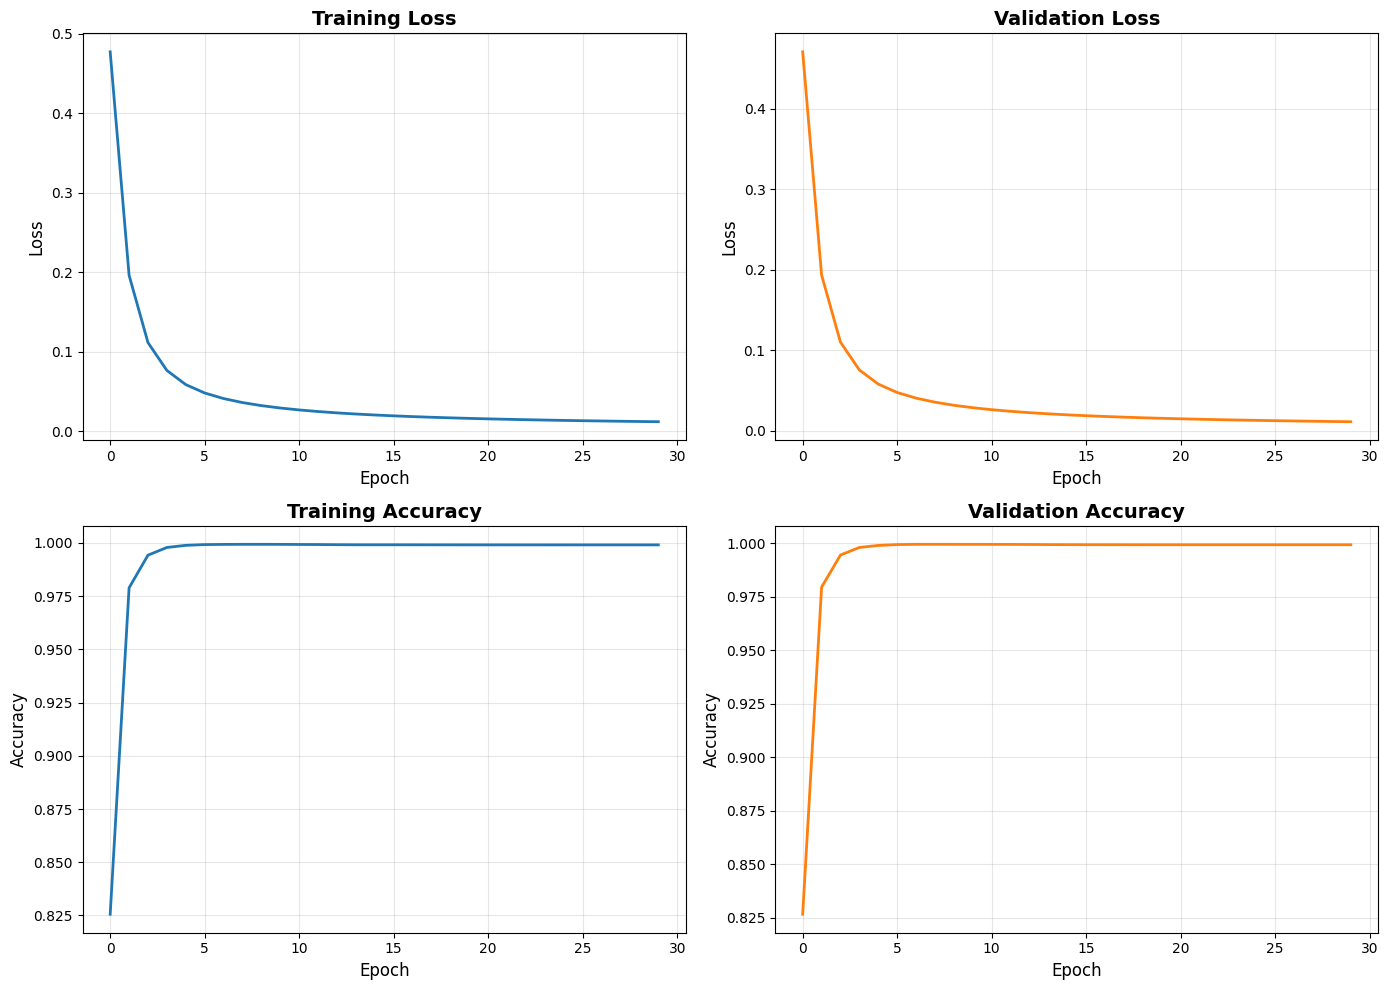

In [81]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training Loss
axes[0, 0].plot(train_losses, color='#1f77b4', linewidth=2)
axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss
axes[0, 1].plot(val_losses, color='#ff7f0e', linewidth=2)
axes[0, 1].set_title('Validation Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Training Accuracy
axes[1, 0].plot(train_accs, color='#1f77b4', linewidth=2)
axes[1, 0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Accuracy', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Validation Accuracy
axes[1, 1].plot(val_accs, color='#ff7f0e', linewidth=2)
axes[1, 1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()